In [25]:
import pandas as pd

# Read the data
cancerData = pd.read_csv("Cancer_Data.csv")
cancerData.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [26]:
# maping the output with 0s and 1s
cancerData['diagnosis'] = cancerData['diagnosis'].map({"M":1, "B":0})

In [56]:
# Separate target from predictors
y = cancerData.diagnosis
X = cancerData.copy()
#X.drop(['diagnosis','id','Unnamed: 32','texture_se','smoothness_se'], axis=1, inplace=True)
X.drop(['diagnosis', 'id', 'concavity_se', 'fractal_dimension_se', 'smoothness_se', 'texture_se','Unnamed: 32'], axis=1, inplace=True)

In [57]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [59]:
# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant', fill_value=0, keep_empty_features=True)

In [60]:
# Define model
model = RandomForestClassifier(n_estimators=100, random_state=0)

In [61]:
# Bundle preprocessing and modeling code in a pipeline
my_pipeline = Pipeline(steps=[('preprocessor', numerical_transformer),
                      ('model', model)
                     ])


In [62]:
# Uses the cross_val_score() function to obtain the mean absolute error (MAE), averaged across i (cv parameter) different folds. 
# in a itteration of 8 times to get the best mae with the amount of folds

from sklearn.model_selection import cross_val_score

best_mae = float('inf')
best_cv = None

for i in range(2, 9):
    scores = -1 * cross_val_score(my_pipeline, X, y, cv=i, scoring='neg_mean_absolute_error')
    mean_score = scores.mean()
    if mean_score < best_mae:
        best_mae = mean_score
        best_cv = i

print(f"Best Average MAE: {best_mae} with cv = {best_cv}")


Best Average MAE: 0.03157396653331613 with cv = 7


In [63]:
# Uses cross_val_score() function to obtain the mean absolute error (MAE), averaged across 7 (best_cv) different folds.

from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, X, y,
                              cv=best_cv,
                              scoring='neg_mean_absolute_error')

print("Average MAE score:", scores.mean())

Average MAE score: 0.03157396653331613


In [64]:
# Function get_score() that reports the average over 7 cross-validation folds MAE
# of a machine learning pipeline

def get_score(n_estimators):
    my_pipeline = Pipeline(steps=[('preprocessor', numerical_transformer),
                      ('model', RandomForestClassifier(n_estimators, random_state=0))
                     ])
    scores = -1 * cross_val_score(my_pipeline, X, y,
                              cv=best_cv,
                              scoring='neg_mean_absolute_error')
    
    return scores.mean()

In [84]:
# Store results in a Python dictionary, where results[i] is the average MAE returned by get_score(i).

results = {}
for i in range(1,9):
    results[50*i] = get_score(50*i)

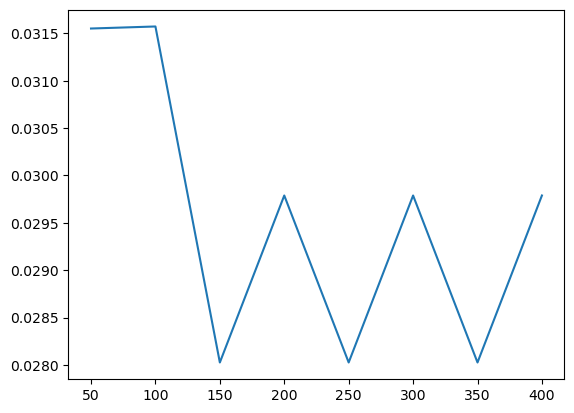

In [85]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(list(results.keys()), list(results.values()))
plt.show()

In [ ]:
# Store results in a Python dictionary, where results[i] is the average MAE returned by get_score(i).

results = {}
for i in range(100, 201, 5):
    results[i] = get_score(i)

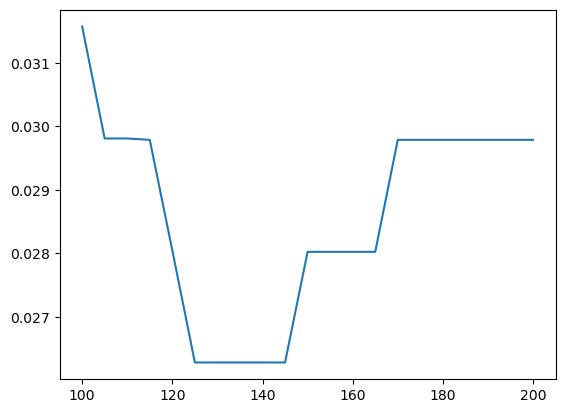

In [80]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(list(results.keys()), list(results.values()))
plt.show()

In [81]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_score_final(n_estimators):
    my_pipeline = Pipeline(steps=[('preprocessor', numerical_transformer),
                      ('model', RandomForestClassifier(n_estimators, random_state=0))
                     ])
    
    # MAE scoring (custom scorer for classification)
    mae_scores = -1 * cross_val_score(my_pipeline, X, y,
                              cv=best_cv,
                              scoring='neg_mean_absolute_error')
    
    # Accuracy scoring
    accuracy_scores = cross_val_score(my_pipeline, X, y, cv=best_cv, scoring='accuracy')

    # Cross-validated predictions for confusion matrix and classification report
    preds = cross_val_predict(my_pipeline, X, y, cv=best_cv)
    cm = confusion_matrix(y, preds)

    print(f"Cross-validated Accuracy: {accuracy_scores.mean()}")
    print(f"Cross-validated MAE: {mae_scores.mean()}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y, preds))

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix Heatmap (RandomForestClassifier)')
    plt.tight_layout()
    plt.show()

Cross-validated Accuracy: 0.9737170387576891
Cross-validated MAE: 0.026282961242310835

Confusion Matrix:
 [[352   5]
 [ 10 202]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       357
           1       0.98      0.95      0.96       212

    accuracy                           0.97       569
   macro avg       0.97      0.97      0.97       569
weighted avg       0.97      0.97      0.97       569



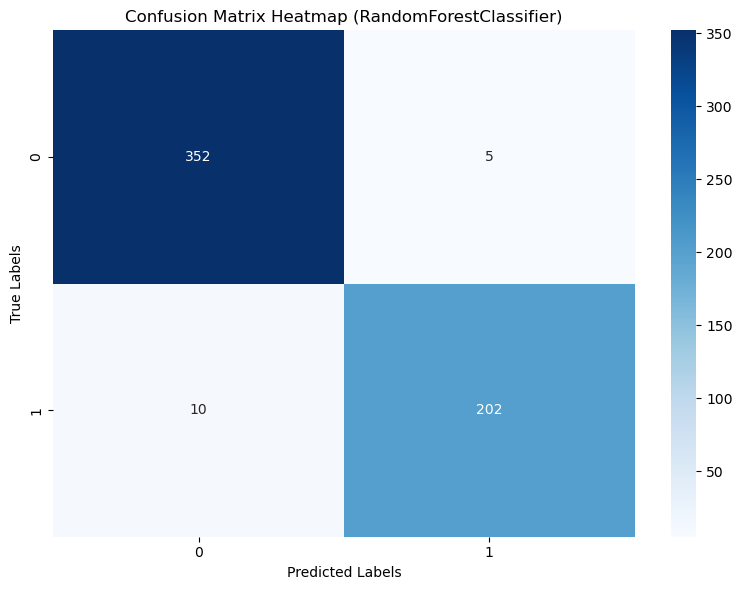

In [83]:
# Exectue the get_score_final() with the best n_estimator value

get_score_final(140)